In [2]:
# ==========================================================
# MULTIMODAL INDOOR RISK DETECTION
# Audio (ESC-50) + Temperature + Humidity (UCI)
# CNN + LSTM + Trend Modeling + Risk Score Output
# ==========================================================

# ===============================
# 1. INSTALL REQUIRED LIBRARIES
# ===============================

# If needed uncomment:
# !pip install librosa torch torchvision pandas numpy scikit-learn matplotlib

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:

# ===============================
# 2. LOAD ESC-50 AUDIO DATA
# ===============================

ESC50_AUDIO_PATH = "ESC-50/audio"
ESC50_META_PATH = "ESC-50/meta/esc50.csv"

meta = pd.read_csv(ESC50_META_PATH)

# Define normal and abnormal categories
normal_classes = [
    "rain", "wind", "chirping_birds",
    "clock_tick", "washing_machine"
]

abnormal_classes = [
    "fire_crackling", "glass_breaking",
    "engine", "siren", "door_wood_knock"
]

meta = meta[meta["category"].isin(normal_classes + abnormal_classes)]
meta["label"] = meta["category"].apply(
    lambda x: 0 if x in normal_classes else 1
)

print("Filtered samples:", len(meta))


Filtered samples: 360


In [4]:
pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ==========================================================
# MULTIMODAL INDOOR RISK DETECTION
# Audio (ESC-50) + Temperature + Humidity (UCI)
# CNN + LSTM + Trend Modeling + Risk Score Output
# ==========================================================

# ===============================
# 1. INSTALL REQUIRED LIBRARIES
# ===============================

# If needed uncomment:
# !pip install librosa torch torchvision pandas numpy scikit-learn matplotlib sentence-transformers

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ===============================
# 2. LOAD ESC-50 AUDIO DATA
# ===============================

ESC50_AUDIO_PATH = "ESC-50/audio"
ESC50_META_PATH = "ESC-50/meta/esc50.csv"

meta = pd.read_csv(ESC50_META_PATH)

print("Total samples before filtering:", len(meta))

# -------------------------------------------------
# SEMANTIC RISK-BASED LABEL ASSIGNMENT (NEW)
# -------------------------------------------------

# Load embedding model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Get unique categories
categories = meta["category"].unique()

# Encode category names
category_embeddings = semantic_model.encode(categories)

# Define risk concept phrases
risk_concepts = [
    "dangerous indoor event",
    "fire hazard",
    "emergency situation",
    "safety risk",
    "accident inside house"
]

# Create averaged risk embedding
risk_embedding = semantic_model.encode(risk_concepts).mean(axis=0)

# Compute cosine similarity between each category and risk concept
risk_scores = cosine_similarity(category_embeddings, [risk_embedding])

# Map category to similarity score
category_risk_map = {}

for i, category in enumerate(categories):
    category_risk_map[category] = risk_scores[i][0]

# Convert similarity score into binary label
RISK_THRESHOLD = 0.35  # You can tune between 0.3 - 0.5

def assign_label(category):
    if category_risk_map[category] > RISK_THRESHOLD:
        return 1  # Abnormal / Risk
    else:
        return 0  # Normal

meta["label"] = meta["category"].apply(assign_label)

print("\nClass distribution after semantic labeling:")
print(meta["label"].value_counts())

print("\nSample category risk scores:")
for k, v in list(category_risk_map.items())[:10]:
    print(f"{k}: {round(v, 3)}")

c:\Users\HAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Total samples before filtering: 2000


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 536.57it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Class distribution after semantic labeling:
label
0    1800
1     200
Name: count, dtype: int64

Sample category risk scores:
dog: 0.22699999809265137
chirping_birds: 0.1379999965429306
vacuum_cleaner: 0.12700000405311584
thunderstorm: 0.35199999809265137
door_wood_knock: 0.22300000488758087
can_opening: 0.24500000476837158
crow: 0.1509999930858612
clapping: 0.23899999260902405
fireworks: 0.47699999809265137
chainsaw: 0.2290000021457672


In [6]:

# ===============================
# 3. AUDIO TO SPECTROGRAM
# ===============================

def extract_mel_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

audio_data = []
audio_labels = []

for idx, row in meta.iterrows():
    path = os.path.join(ESC50_AUDIO_PATH, row["filename"])
    try:
        mel = extract_mel_spectrogram(path)
        mel = mel[:, :128]  # truncate for fixed size
        if mel.shape[1] < 128:
            pad_width = 128 - mel.shape[1]
            mel = np.pad(mel, ((0,0),(0,pad_width)))
        audio_data.append(mel)
        audio_labels.append(row["label"])
    except:
        continue

audio_data = np.array(audio_data)
audio_labels = np.array(audio_labels)

print("Audio shape:", audio_data.shape)


Audio shape: (2000, 128, 128)


In [7]:

# ===============================
# 4. LOAD TEMPERATURE + HUMIDITY
# ===============================

UCI_PATH = "D:\\College\\Semester- 8\\IOT\\energydata_complete.csv"
climate_df = pd.read_csv(UCI_PATH)

# Keep only needed columns
climate_df = climate_df[["T1", "RH_1"]]

scaler = MinMaxScaler()
climate_scaled = scaler.fit_transform(climate_df)

# Create sequences
SEQ_LEN = 12

def create_sequences(data):
    sequences = []
    for i in range(len(data) - SEQ_LEN):
        seq = data[i:i+SEQ_LEN]
        sequences.append(seq)
    return np.array(sequences)

climate_sequences = create_sequences(climate_scaled)

# Compute trend features
def add_trend_features(seq):
    temp = seq[:,0]
    hum = seq[:,1]
    dT = np.gradient(temp)
    dH = np.gradient(hum)
    return np.stack([temp, hum, dT, dH], axis=1)

climate_sequences = np.array([add_trend_features(seq) for seq in climate_sequences])

print("Climate shape:", climate_sequences.shape)

# Match dataset sizes
min_len = min(len(audio_data), len(climate_sequences))
audio_data = audio_data[:min_len]
audio_labels = audio_labels[:min_len]
climate_sequences = climate_sequences[:min_len]

# Train-test split
X_audio_train, X_audio_test, \
X_climate_train, X_climate_test, \
y_train, y_test = train_test_split(
    audio_data,
    climate_sequences,
    audio_labels,
    test_size=0.2,
    random_state=42
)


Climate shape: (19723, 12, 4)


In [8]:

# ===============================
# 5. DATASET CLASS
# ===============================

class MultimodalDataset(Dataset):
    def __init__(self, audio, climate, labels):
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.climate = torch.tensor(climate, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.audio[idx].unsqueeze(0),
            self.climate[idx],
            self.labels[idx]
        )

train_dataset = MultimodalDataset(X_audio_train, X_climate_train, y_train)
test_dataset = MultimodalDataset(X_audio_test, X_climate_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [9]:
# ==========================================================
# ADVANCED MULTIMODAL MODEL (ATTENTION + CLASS WEIGHTING)
# ==========================================================

class AdvancedMultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()

        # ======================
        # DEEPER CNN BRANCH
        # ======================
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        # ======================
        # BIDIRECTIONAL LSTM
        # ======================
        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # ======================
        # ATTENTION FUSION
        # ======================
        self.attention = nn.Sequential(
            nn.Linear(128 + 256, 256),
            nn.Tanh(),
            nn.Linear(256, 128 + 256),
            nn.Sigmoid()
        )

        # ======================
        # FINAL CLASSIFIER
        # ======================
        self.classifier = nn.Sequential(
            nn.Linear(128 + 256, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # No sigmoid here!
        )

    def forward(self, audio, climate):

        # CNN branch
        a = self.cnn(audio)
        a = a.view(a.size(0), -1)

        # LSTM branch
        lstm_out, (h, _) = self.lstm(climate)
        c = torch.cat((h[-2], h[-1]), dim=1)  # bidirectional concat

        # Fusion
        fused = torch.cat((a, c), dim=1)

        # Attention weighting
        weights = self.attention(fused)
        fused = fused * weights

        # Classification
        out = self.classifier(fused)

        return out


model = AdvancedMultimodalModel().to(device)


In [10]:
# ==========================================================
# CLASS BALANCING + FOCAL LOSS + EARLY STOPPING (FINAL)
# ==========================================================

from torch.utils.data import WeightedRandomSampler

# ---------- Weighted Sampler ----------
class_counts = np.bincount(y_train.astype(int))
class_weights = 1. / class_counts
sample_weights = class_weights[y_train.astype(int)]
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# ---------- Improved Focal Loss ----------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion = FocalLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)


# ==========================================================
# TRAINING LOOP WITH EARLY STOPPING
# ==========================================================

EPOCHS = 40
best_val_loss = float("inf")
patience = 6
counter = 0

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for audio, climate, labels in train_loader:
        audio = audio.to(device)
        climate = climate.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(audio, climate)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATE --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for audio, climate, labels in val_loader:
            audio = audio.to(device)
            climate = climate.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(audio, climate)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


# Load best model
model.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded.")

Epoch 1/40 | Train Loss: 0.1330 | Val Loss: 0.1167
Epoch 2/40 | Train Loss: 0.1117 | Val Loss: 0.2734
Epoch 3/40 | Train Loss: 0.1029 | Val Loss: 0.1041
Epoch 4/40 | Train Loss: 0.0966 | Val Loss: 0.1444
Epoch 5/40 | Train Loss: 0.0886 | Val Loss: 0.0665
Epoch 6/40 | Train Loss: 0.0790 | Val Loss: 0.0882
Epoch 7/40 | Train Loss: 0.0829 | Val Loss: 0.1824
Epoch 8/40 | Train Loss: 0.0782 | Val Loss: 0.0489
Epoch 9/40 | Train Loss: 0.0703 | Val Loss: 0.0607
Epoch 10/40 | Train Loss: 0.0719 | Val Loss: 0.0646
Epoch 11/40 | Train Loss: 0.0668 | Val Loss: 0.1175
Epoch 12/40 | Train Loss: 0.0648 | Val Loss: 0.0762
Epoch 13/40 | Train Loss: 0.0577 | Val Loss: 0.0947
Epoch 14/40 | Train Loss: 0.0539 | Val Loss: 0.3836
Early stopping triggered.
Best model loaded.


Best threshold: 0.5400000000000003

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       370
         1.0       0.59      0.63      0.61        30

    accuracy                           0.94       400
   macro avg       0.78      0.80      0.79       400
weighted avg       0.94      0.94      0.94       400

AUC Score: 0.9164864864864866


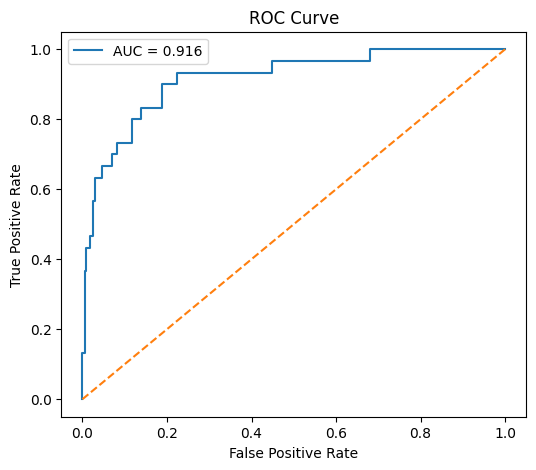

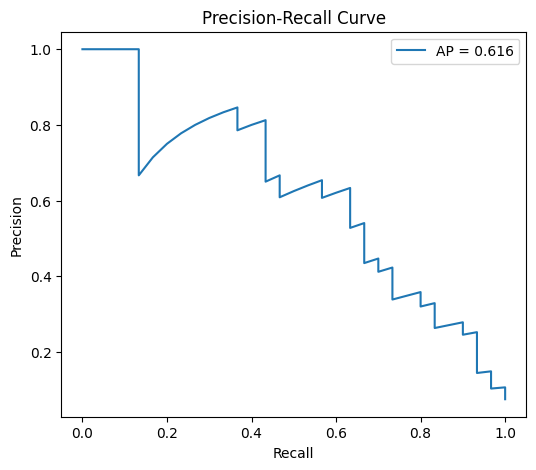

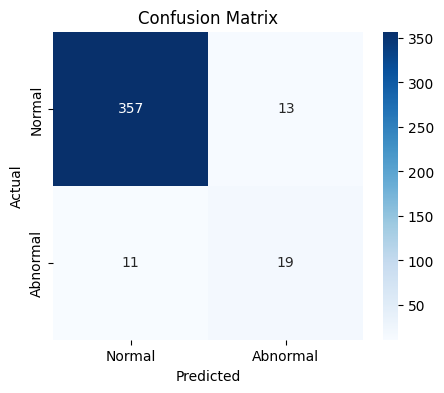

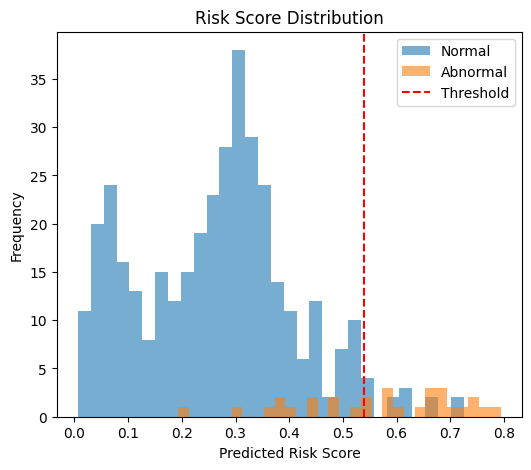

In [11]:
# ======================
# EVALUATION + VISUALIZATION
# ======================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for audio, climate, labels in test_loader:
        audio = audio.to(device)
        climate = climate.to(device)

        outputs = model(audio, climate)
        probs = torch.sigmoid(outputs)
        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels)

# ======================
# THRESHOLD OPTIMIZATION
# ======================

from sklearn.metrics import f1_score

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.3, 0.9, 0.01):
    preds = (all_preds > t).astype(int)
    f1 = f1_score(all_labels, preds, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)

binary_preds = (all_preds > best_thresh).astype(int)

print("\nClassification Report:")
print(classification_report(all_labels, binary_preds))

print("AUC Score:", roc_auc_score(all_labels, all_preds))


# ======================
# 1️⃣ ROC CURVE
# ======================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_preds)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(all_labels, all_preds):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# ======================
# 2️⃣ PRECISION-RECALL CURVE
# ======================

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_preds)
ap = average_precision_score(all_labels, all_preds)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


# ======================
# 3️⃣ CONFUSION MATRIX
# ======================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, binary_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Abnormal"],
            yticklabels=["Normal","Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ======================
# 4️⃣ RISK SCORE DISTRIBUTION
# ======================

plt.figure(figsize=(6,5))
plt.hist(all_preds[all_labels==0], bins=30, alpha=0.6, label="Normal")
plt.hist(all_preds[all_labels==1], bins=30, alpha=0.6, label="Abnormal")
plt.axvline(best_thresh, color='red', linestyle='--', label="Threshold")
plt.xlabel("Predicted Risk Score")
plt.ylabel("Frequency")
plt.title("Risk Score Distribution")
plt.legend()
plt.show()